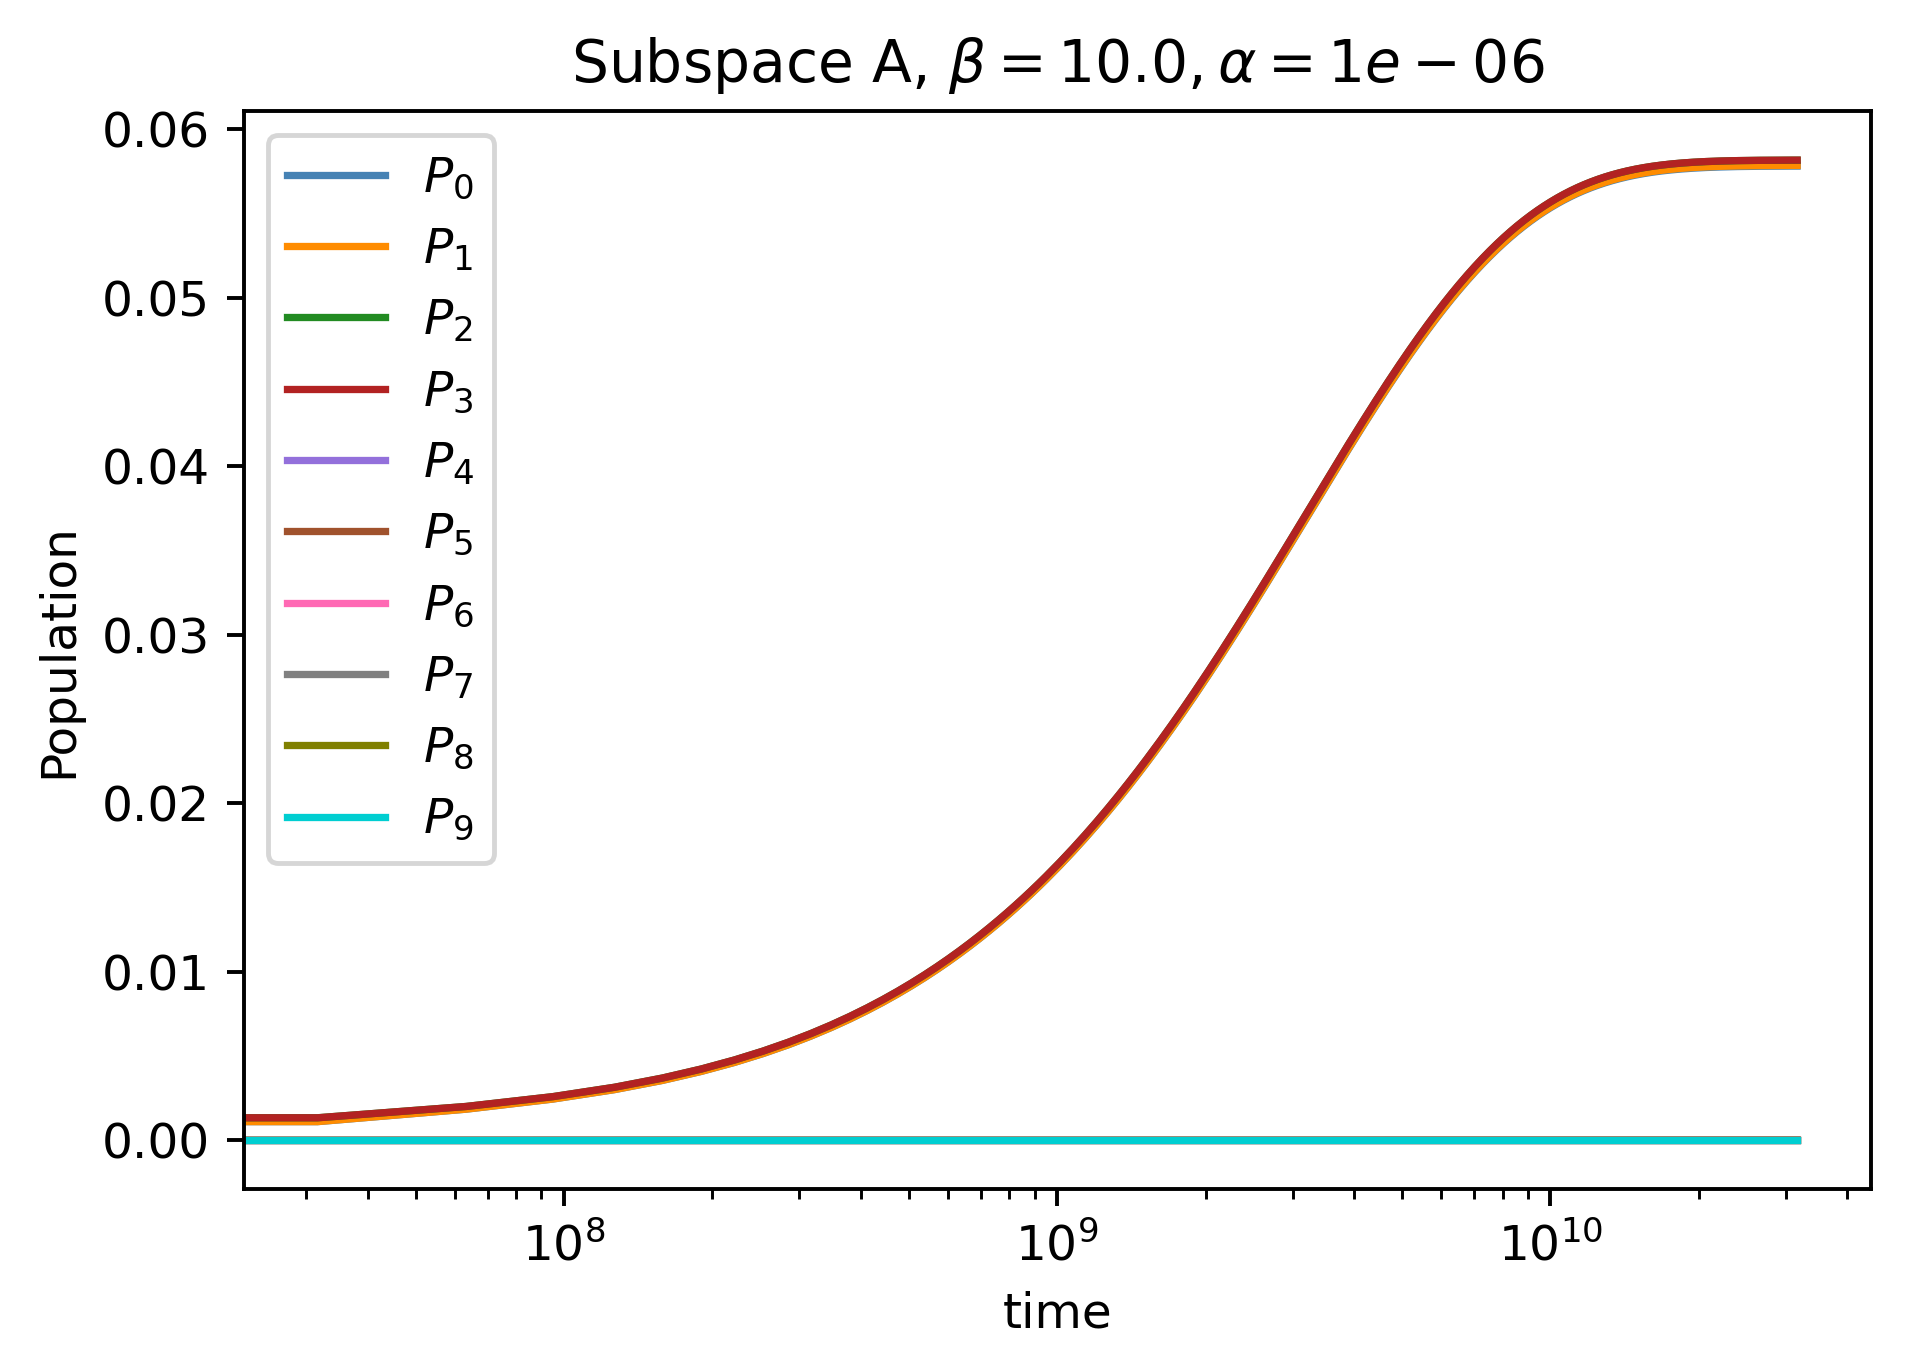

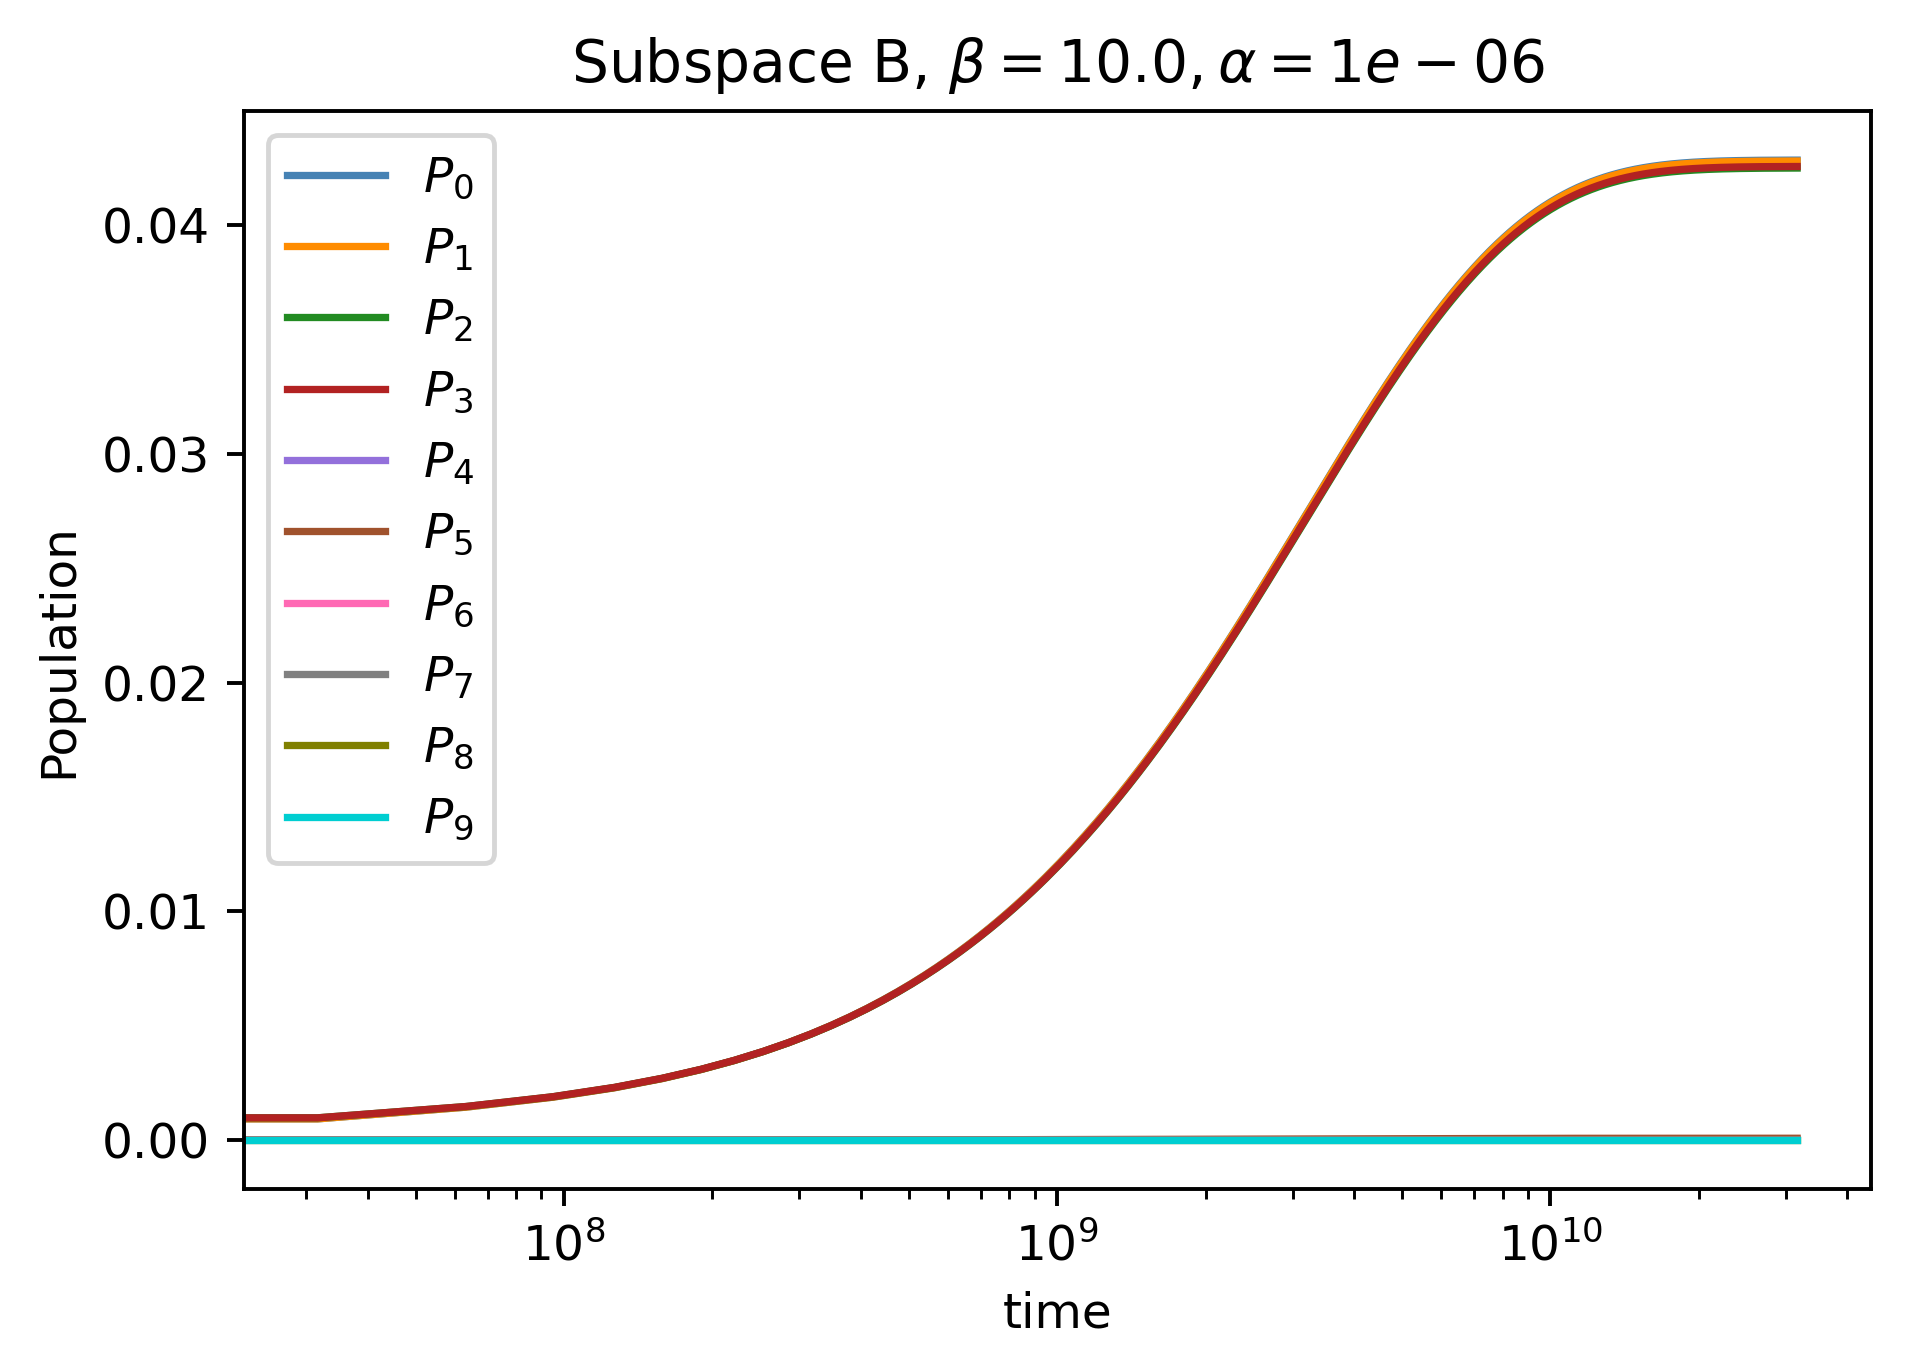

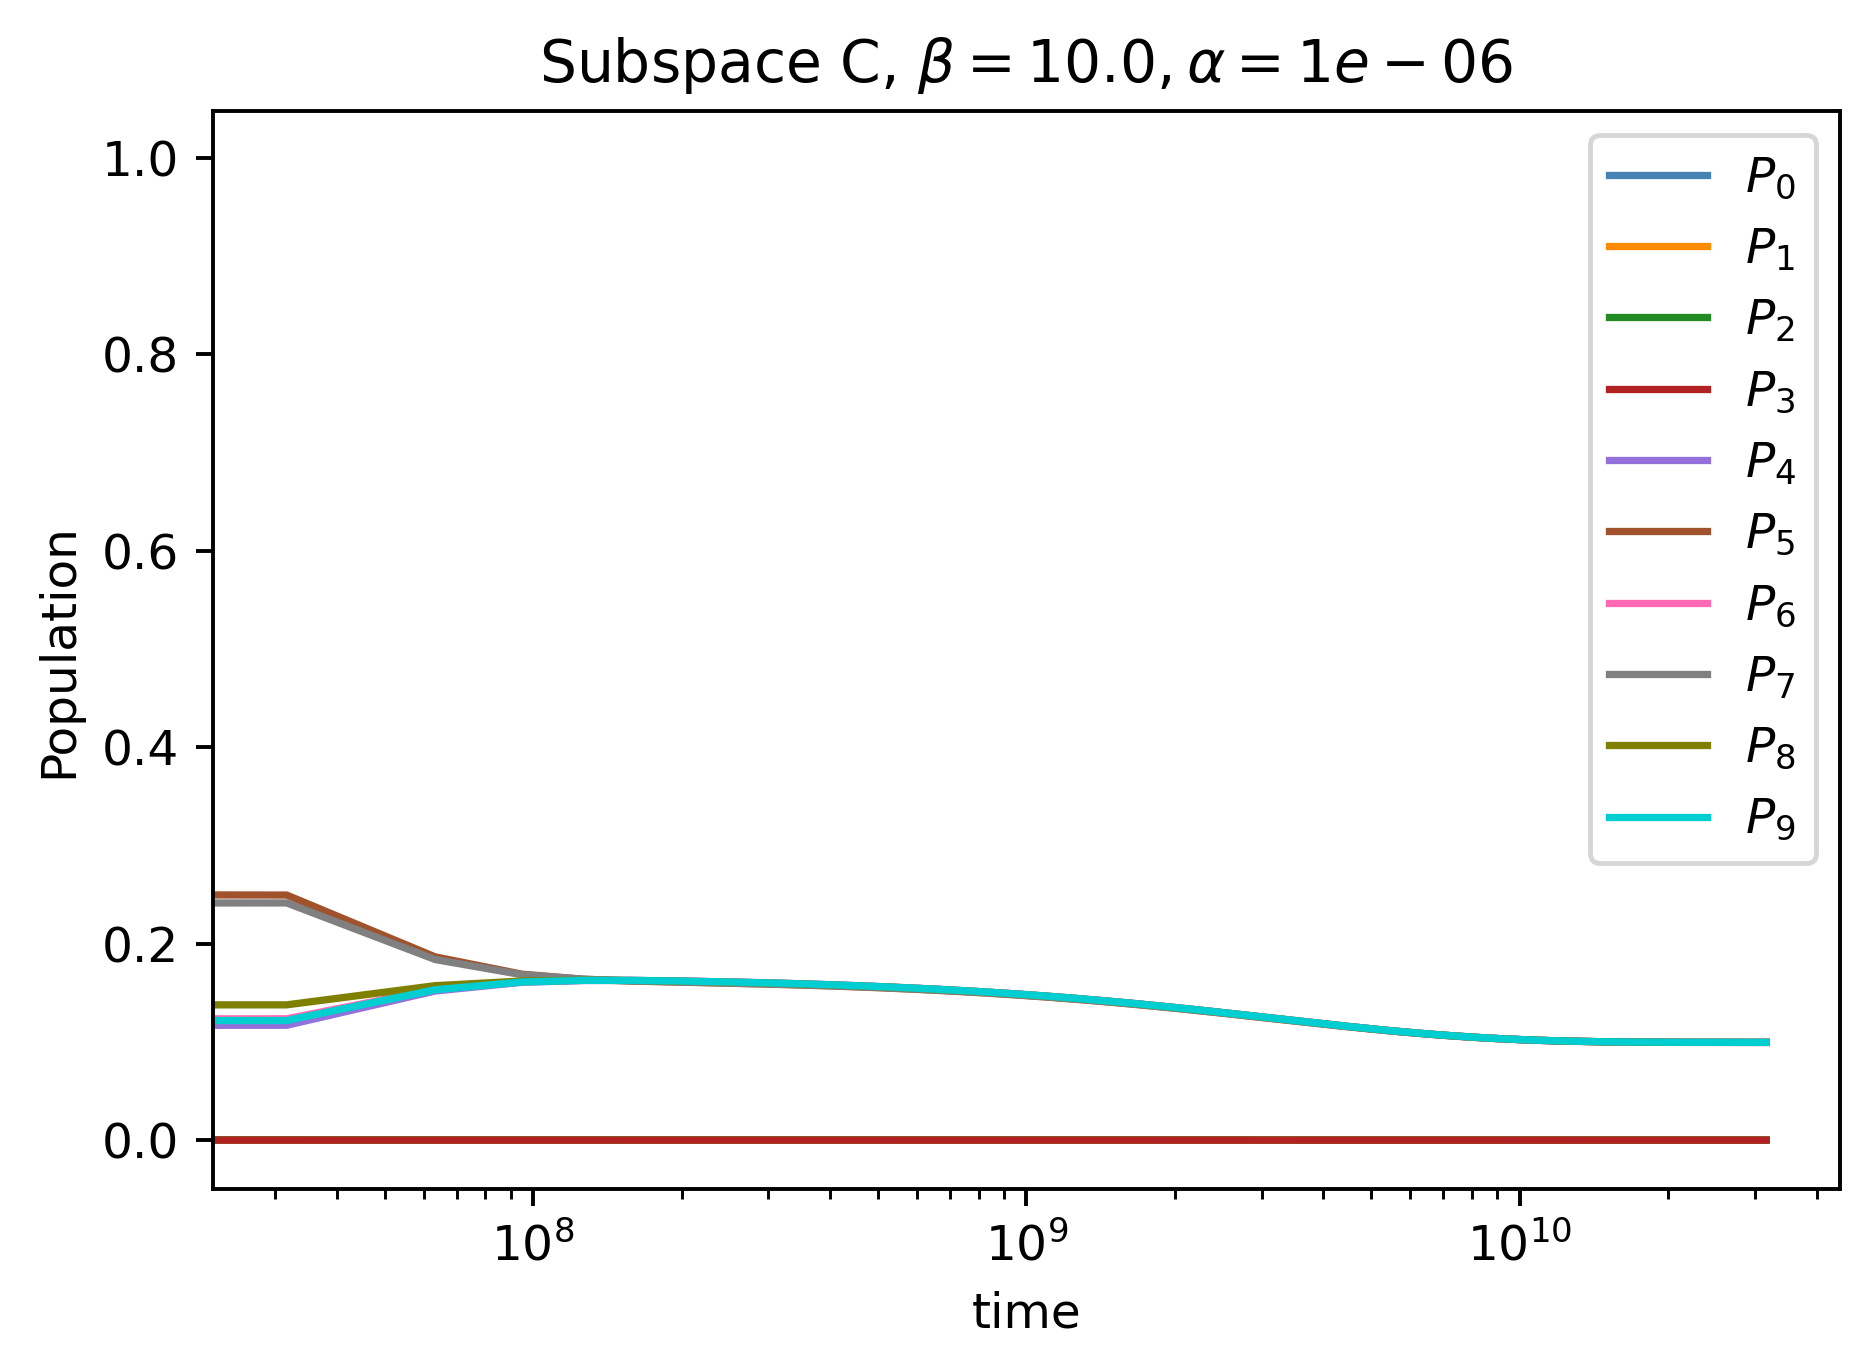

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

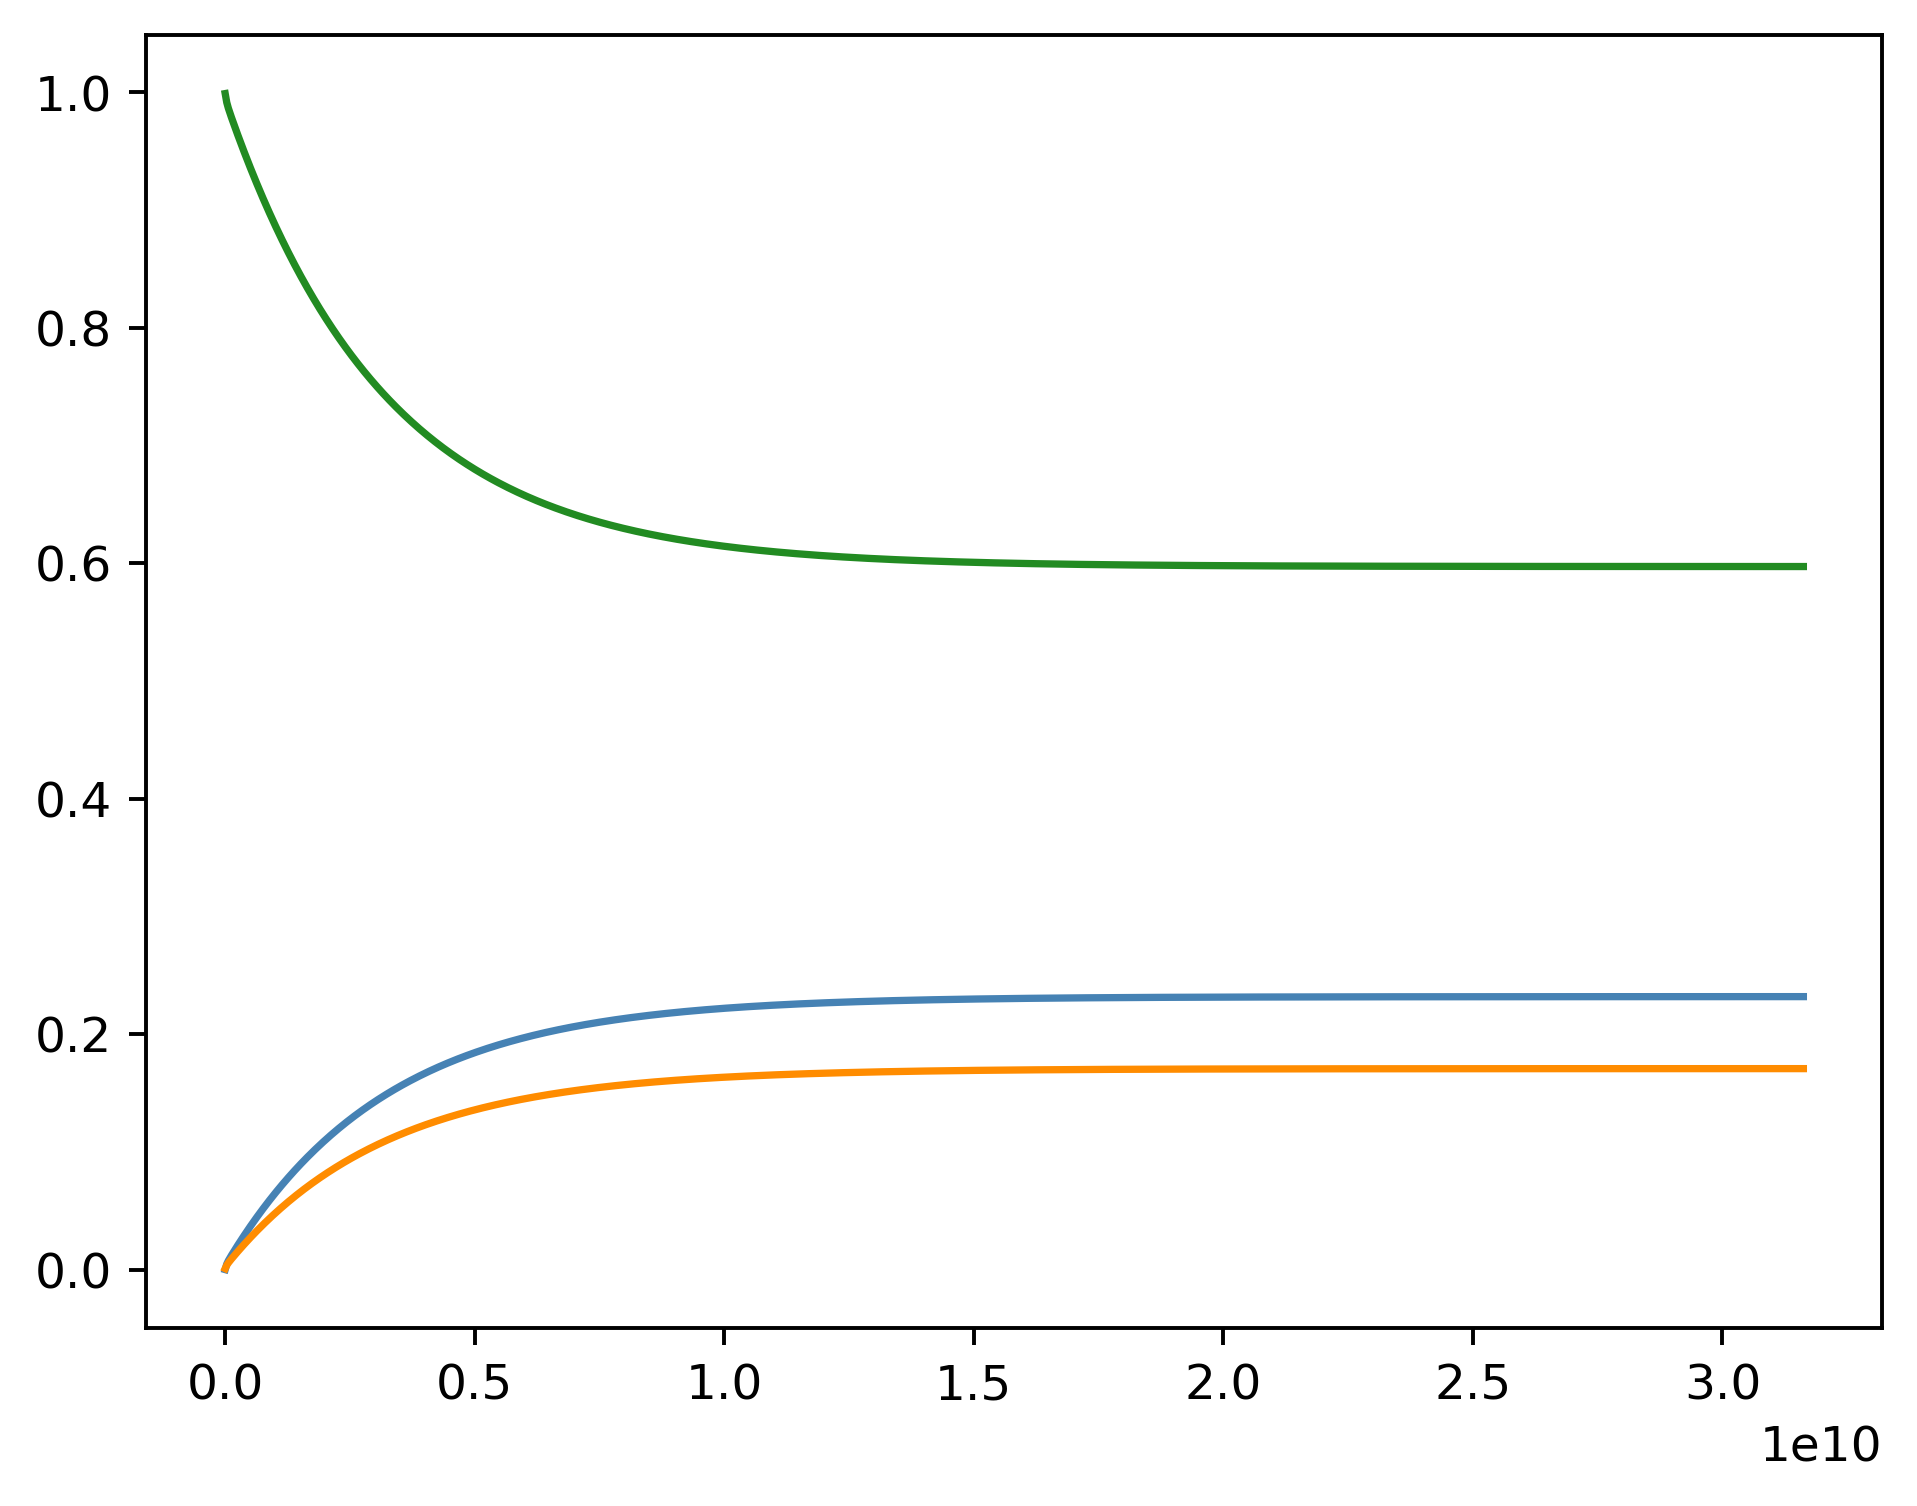

In [1]:
%matplotlib inline
import numpy as np
from utils import _build_redfield_numba, build_redfield_tensor
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from matplotlib.colors import LogNorm
plt.rcParams['figure.dpi']=350

#coupling params
J_max = 1
power = 3 #power for coupling matrix/system hamiltonain - 3 for dipole-dipole like model

#bath params- assuming 3 decoupled ohmic baths
alpha_list=np.array(1e-6*np.ones(10))
wc_list=np.array(50*np.ones(10))
beta_list=np.array(10*np.ones(10))

#generate configuration B using Roi's code 
D = np.array([[ 26.42338043,  -7.94752626],
              [ 23.5676572 , -10.82584156],
              [ 12.9945502 , -15.04985626],
              [ 10.04355896, -17.75500788],
              [ 22.09827259,  11.50615309],
              [  4.77769072, -29.50708222],
              [  3.61769485,  13.64602815],
              [-13.15603736,  -3.06908283],
              [ -7.72037927,  25.74900317],
              [-22.17787943,  18.52470886]])

#config A coupling matrix 
'''D=np.array([[ 31.53553015,   3.44199744],
              [ 29.69692277,   2.38201959],
              [ 29.78424968,   6.90942031],
              [ 11.22998167,   8.6657443 ],
              [ 11.4583447 ,  -2.66983921],
              [ 13.21948377, -17.481802  ],
              [  0.64608129,  21.77132371],
              [  5.82726916, -30.27930513],
              [-15.20226319, -15.91983595],
              [-15.69793743,  24.45663107]])
'''
#system hamiltonian in local basis, degenerate case
N = D.shape[0]
H = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            dist = np.linalg.norm(D[i] - D[j])
            H[i, j] = J_max / dist**power
#plot spectrum

energies,evectors=np.linalg.eigh(H)
'''
plt.figure()
for energy,k in zip(energies,range(len(energies))):
    x=1/2*np.linspace(k,k+1)
    plt.plot(x,energy*np.ones_like(x),color='r',lw=1)
plt.ylabel('Energy')
plt.title('System Hamiltonian Spectrum')
plt.xticks([])
plt.show()
'''



#system-bath coupling operators 
S_list=[]
for i in range(H.shape[0]):
    S=np.zeros((H.shape[0],H.shape[0]))
    S[i,i]=1
    S_list.append(S)
def dens(alpha, wc, x): #J(w) spectral density function for baths
    return 2 * alpha * x * np.exp(-x / wc)

def eta(beta, x):  #the thermal factor
    return 1 / np.expm1(beta * x)  # better than exp(beta*x)-1 near x=0

def gamma_func(w): #Laplace transforms of bath correlation functions 
    gammas = []
    absw = abs(w)
    for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

        if absw < 1e-12:
            # Ohmic zero-frequency limit:
            # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
            g = (np.pi/2)*(alpha/beta)
        elif w > 0:
            g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
        else:
            g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
        gammas.append(g + 0j) #ensures dtype is complex with 0 complex part
   
    return np.array(gammas, dtype=np.complex128)

R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-8,True) 

#initial condition and time array
rho_init=np.zeros((10,10))
rho_init[5,5]=1   #initial density matrix in local basis - state |A><A|
time_steps=np.linspace(0,10**10.5,1*(10**3))

#time eveolve
def evolve_density_matrix(R, time_steps, rho_init, U=None, n_jobs=-1, energy_basis=False):

    time_steps = np.array(time_steps)
    N = rho_init.shape[0]
    if U is None:
        U = np.eye(N)
    eigvals, eigvecs = np.linalg.eig(R)

    rho_energy = U.conj().T @ rho_init @ U
    rho_vec = rho_energy.reshape(-1)

    def evolve_single(t):
        U_t = eigvecs @ np.diag(np.exp(eigvals * t)) @ np.linalg.inv(eigvecs)
        rho_vec_t = U_t @ rho_vec
        rho_matrix_t = rho_vec_t.reshape(N, N)

        # ensure unital trace and hermiticity
        rho_matrix_t = 0.5 * (rho_matrix_t + rho_matrix_t.conj().T)
        rho_matrix_t /= np.trace(rho_matrix_t)
        
        proj_A = np.diag([1,1,0,0,0,0,0,0,0,0])
        proj_C = np.diag([0,0,1,1,1,1,1,1,0,0])
        proj_B = np.diag([0,0,0,0,0,0,0,0,1,1])
        
        
            
        # return to original basis
        if energy_basis:
            return rho_matrix_t
        else:
            return U @ proj_A@rho_matrix_t @proj_A@ U.conj().T, U @ proj_B@rho_matrix_t @proj_B@ U.conj().T, U @ proj_C@rho_matrix_t @proj_C@ U.conj().T

    results = Parallel(n_jobs=n_jobs)(
        delayed(evolve_single)(t) for t in time_steps
    )

    rho_t_A, rho_t_B, rho_t_C = map(np.array, zip(*results))

    return rho_t_A, rho_t_B, rho_t_C



rho_t_A,rho_t_B,rho_t_C=evolve_density_matrix(R, time_steps, rho_init, U, n_jobs=-1, energy_basis=False)
rho_t_A,rho_t_B,rho_t_C=np.array(rho_t_A),np.array(rho_t_B),np.array(rho_t_C)

RHOS=[rho_t_A,rho_t_B,rho_t_C]

#populations in each site
populations=[]
for RHO in RHOS:
    populations.append(np.diagonal(RHO, axis1=-2, axis2=-1).real)
populations=np.array(populations)
'''
ss=sum(populations[:,-1])
print('trace=',ss)
#print(rho_t[-1]-rho_t[-1].conj().T)
#final long time limit Gibbs state of the system
'''
#plot
colours=['steelblue','darkorange','forestgreen','firebrick','mediumpurple','sienna','hotpink','grey','olive','darkturquoise']
    
subspace_names = ['A', 'B', 'C']

strong=np.average([H[0,1],H[2,3]])
i, j = np.triu_indices(N, k=1)

mask = (i <= 3) & (j > 3)

weak = np.sqrt(H[i[mask], j[mask]])
Beta=beta_list[0]
Alpha=alpha_list[0]
expression=-((np.pi*Alpha)/(2*strong))*(-weak**2+(weak**2+weak**2)/np.tanh(strong*Beta/2))*(2+1/np.cosh(strong*Beta))

R_eigvals=np.sort_complex(np.linalg.eigvals(R))

ss_index = np.argmax(R_eigvals.real)
R_eigvals = np.delete(R_eigvals, ss_index)
gap = np.max(R_eigvals.real)

for j in range(3):
    plt.figure(figsize=(6,4))

    for k in range(H.shape[0]):
        plt.plot(
            time_steps,
            populations[j, :, k],
            color=colours[k],
            label=f'$P_{k}$'
        )

    plt.xlabel('time')
    plt.ylabel('Population')
    plt.xscale('log')
    plt.legend()
    plt.title(
        f'Subspace {subspace_names[j]}, '
        f'$\\beta={beta_list[0]},\\alpha={alpha_list[0]}$'
    )
    plt.show()

# total population in each subspace
pop_A = populations[0].sum(axis=1)
pop_B = populations[1].sum(axis=1)
pop_C = populations[2].sum(axis=1)

plt.figure()
plt.plot(time_steps,pop_A,color='steelblue',label='Pop A')
plt.plot(time_steps,pop_B,color='darkorange',label='Pop B')
plt.plot(time_steps,pop_C,color='forestgreen',label='Pop C')
plt.axvline(x=-1/expression, color='red', linestyle='--')
plt.axvline(x=-1/gap, color='pink', linestyle='--')
plt.legend()
plt.xlabel('time')
plt.ylabel('populations in subspaces')
plt.xscale('log')
plt.show()

In [14]:
H = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            dist = np.linalg.norm(D[i] - D[j])
            H[i, j] = J_max / dist**power

Hnew=H[4:,4:]
energies,evectors=np.linalg.eigh(Hnew)

print(energies)


[-3.14836923e-04 -1.38521693e-04 -4.08263144e-05  1.56752833e-05
  6.65417742e-05  4.11967872e-04]


In [33]:
H=[[0,E,E],
  [E,0,E],
  [E,E,0]]


[[0.00000000e+00 1.50021347e-02 2.85241309e-04 1.43707710e-04
  1.26346886e-04 3.50697740e-05 3.22799629e-05 1.57677352e-05
  9.05844417e-06 5.89941463e-06]
 [1.50021347e-02 0.00000000e+00 6.77527904e-04 2.84985635e-04
  8.92078898e-05 5.37584151e-05 3.17716658e-05 1.89115598e-05
  8.96822326e-06 6.22816689e-06]
 [2.85241309e-04 6.77527904e-04 0.00000000e+00 1.55867074e-02
  4.51989670e-05 2.17465791e-04 3.63455573e-05 4.20177600e-05
  1.04385998e-05 8.69825252e-06]
 [1.43707710e-04 2.84985635e-04 1.55867074e-02 0.00000000e+00
  3.15502623e-05 4.68234740e-04 3.03699040e-05 4.83093733e-05
  9.63729673e-06 8.75324033e-06]
 [1.26346886e-04 8.92078898e-05 4.51989670e-05 3.15502623e-05
  0.00000000e+00 1.13322355e-05 1.55302068e-04 1.80123125e-05
  2.77114731e-05 1.11000089e-05]
 [3.50697740e-05 5.37584151e-05 2.17465791e-04 4.68234740e-04
  1.13322355e-05 0.00000000e+00 1.24306299e-05 3.06708156e-05
  5.49992507e-06 5.98481268e-06]
 [3.22799629e-05 3.17716658e-05 3.63455573e-05 3.03699040e

In [26]:
weak

np.float64(0.00011378771789289194)

In [28]:
((strong-2*avg)**2-strong**2)/8

np.float64(-8.640959574023097e-07)